# Closing the water balance

This notebook uses different data sources to compare them and close the water balance using Kalman filtering and smoothing.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# useful imports
from scipy.stats import norm#the normal distribution
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
%matplotlib inline

# PART 1: Errors in water balance data

# Precipitation

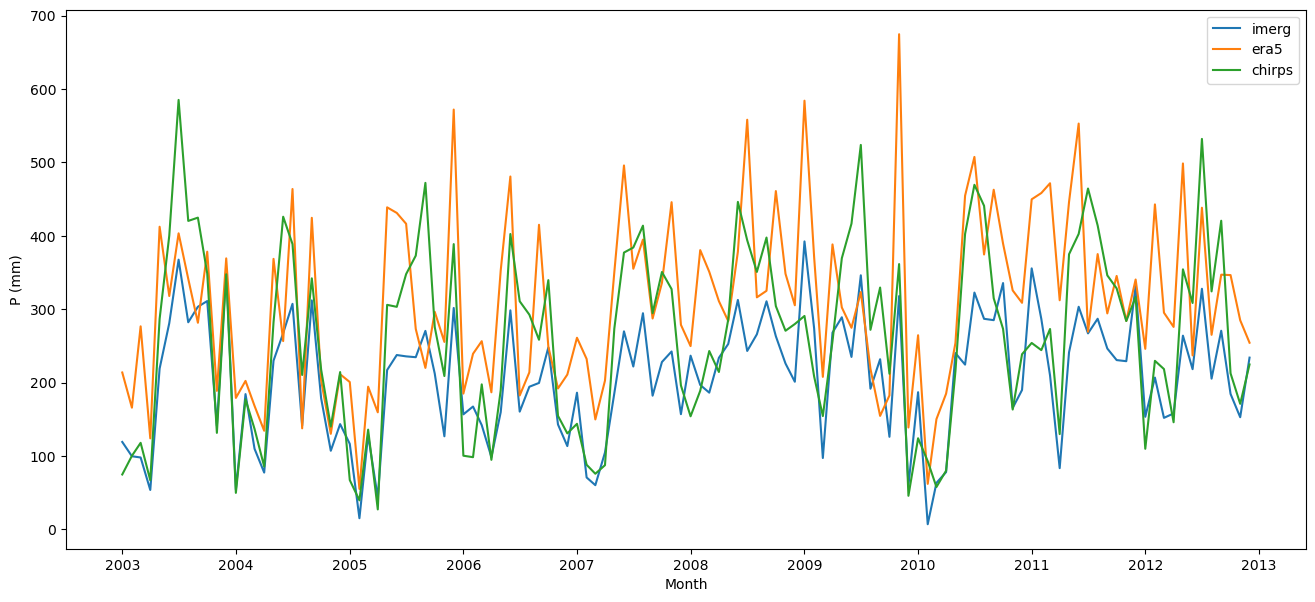

In [3]:
# Loading the data
imerg = pd.read_csv('./Data/imerg_30min.csv', ) # mm/hour
era5P = pd.read_csv('./Data/era5P_daily.csv') # m/day 
chirps = pd.read_csv('./Data/chirps_daily.csv') # mm/day

# Setting the units to mm/month
imerg['date'] = pd.to_datetime(imerg['system:index'], format='%Y%m%d%H%M%S')
imerg.set_index('date', inplace=True)
imerg.drop(columns=['system:index'], inplace=True)
imerg = imerg.resample('D').sum() / 2 # mm/day
imerg_monthly = imerg.resample('MS').sum() # mm/month

era5P['date'] = pd.to_datetime(era5P['system:index'], format='%Y%m%d')
era5P.set_index('date', inplace=True)
era5P.drop(columns=['system:index'], inplace=True)
era5P['total_precipitation_sum'] = era5P['total_precipitation_sum'] * 1000 # mm/day
era5P_monthly = era5P.resample('MS').sum() # mm/month

chirps['date'] = pd.to_datetime(chirps['system:index'], format='%Y%m%d')
chirps.set_index('date', inplace=True)
chirps.drop(columns=['system:index'], inplace=True)
chirps_monthly = chirps.resample('MS').sum() # mm/month

# Plotting the data
plt.figure(figsize=(16,7))
plt.plot(imerg_monthly['precipitation'], label='imerg')
plt.plot(era5P_monthly['total_precipitation_sum'], label='era5')
plt.plot(chirps_monthly['precipitation'], label='chirps')
plt.legend()
plt.xlabel('Month') 
plt.ylabel('P (mm)');
plt.rcParams["font.size"] = 12

In [4]:
# Compute monthly mean mP and variance vP of precipitation
PObs1 = imerg_monthly['precipitation']
PObs2 = era5P_monthly['total_precipitation_sum']
PObs3 = chirps_monthly['precipitation']

mP = (PObs1 + PObs2 + PObs3) / 3
vP = (np.square(PObs1 - mP) + np.square(PObs2 - mP) + np.square(PObs3 - mP)) / 2
print(mP[0], vP[0])

135.8796938119277 5035.483265605889


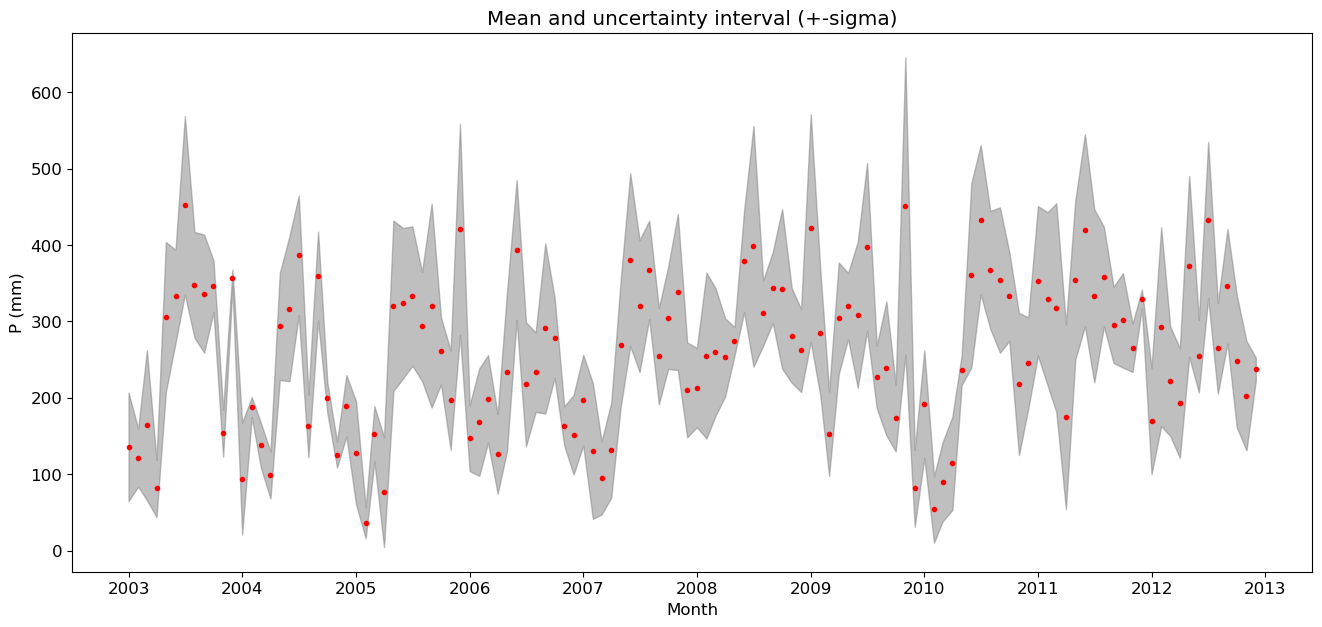

In [5]:
# Plot monthly mean and uncertainty interval (+-sigma) of precipitation.
# The plt.fill_between() function is useful for plotting an uncertainty interval.
plt.figure(figsize=(16,7))
plt.fill_between(imerg_monthly.index, mP - np.sqrt(vP), mP + np.sqrt(vP), color='grey', alpha=0.5)
plt.plot(mP, 'r.')
plt.xlabel('Month')
plt.ylabel('P (mm)')
plt.title('Mean and uncertainty interval (+-sigma)');

# Evaporation

In [6]:
# Loading the data
gldas = pd.read_csv('./Data/gldas_3hour.csv') # mm/s
era5E = pd.read_csv('./Data/era5E_daily.csv') # m/day
mod16 = pd.read_csv('./Data/mod16_8day.csv') # 0.1 mm/8days

# Setting the units to mm/month
gldas['date'] = pd.to_datetime(gldas['system:index'], format='A%Y%m%d_%H%M')
gldas.set_index('date', inplace=True)
gldas.drop(columns=['system:index'], inplace=True)
gldas['Evap_tavg'] = gldas['Evap_tavg'] * 10800 # mm/3hr
gldas = gldas.resample('D').sum() # mm/day
gldas_monthly = gldas.resample('MS').sum() # mm/month

era5E['date'] = pd.to_datetime(era5E['system:index'], format='%Y%m%d')
era5E.set_index('date', inplace=True)
era5E.drop(columns=['system:index'], inplace=True)
era5E['total_evaporation_sum'] = era5E['total_evaporation_sum'] * -1000 # mm/day
era5E_monthly = era5E.resample('MS').sum() # mm/month

mod16['date'] = pd.to_datetime(mod16['system:index'], format='%Y_%m_%d')
mod16.set_index('date', inplace=True)
mod16.drop(columns=['system:index'], inplace=True)
mod16['ET'] = mod16['ET'] * 0.1 # mm/8days
mod16_monthly = mod16.resample('MS').sum() # mm/month

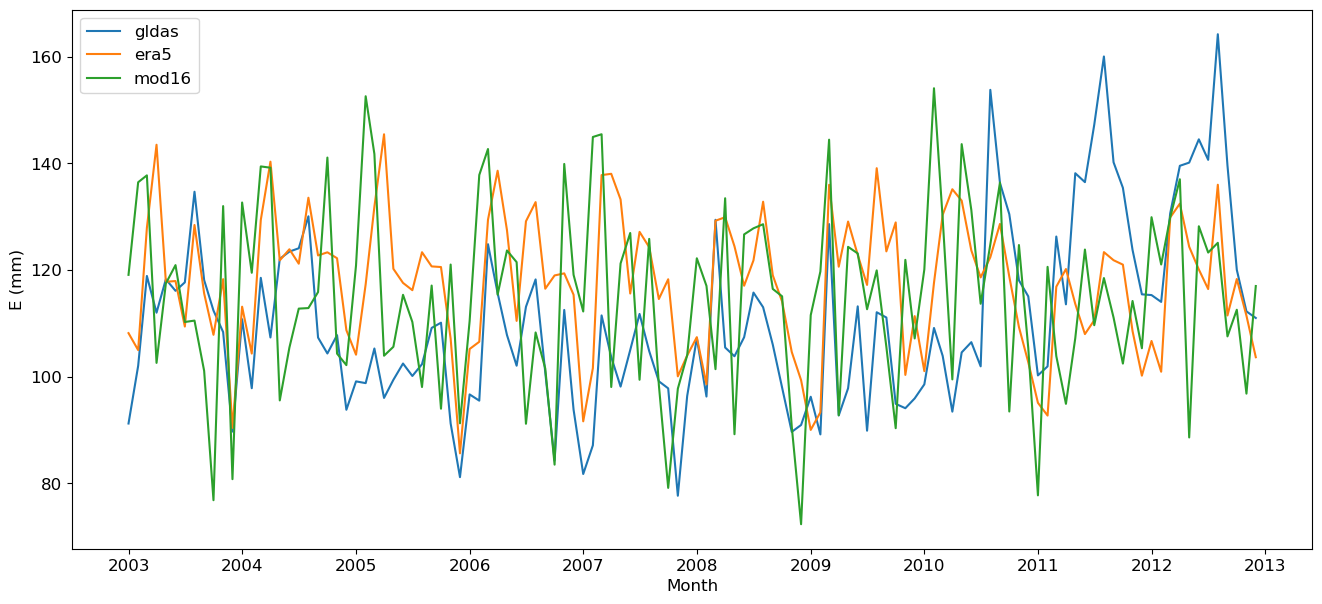

In [7]:
# Plotting the data
plt.figure(figsize=(16,7))
plt.plot(gldas_monthly['Evap_tavg'], label='gldas')
plt.plot(era5E_monthly['total_evaporation_sum'], label='era5')
plt.plot(mod16_monthly['ET'], label='mod16')
plt.legend()
plt.xlabel('Month')
plt.ylabel('E (mm)');
plt.rcParams["font.size"] = 12

In [8]:
# Compute monthly mean mP and variance vP of precipitation
EObs1 = gldas_monthly['Evap_tavg']
EObs2 = era5E_monthly['total_evaporation_sum']
EObs3 = mod16_monthly['ET']

mE = (EObs1 + EObs2 + EObs3) / 3
vE = (np.square(EObs1 - mE) + np.square(EObs2 - mE) + np.square(EObs3 - mE)) / 2
print(mE[0], vE[0])

106.15445378153599 197.47753066427225


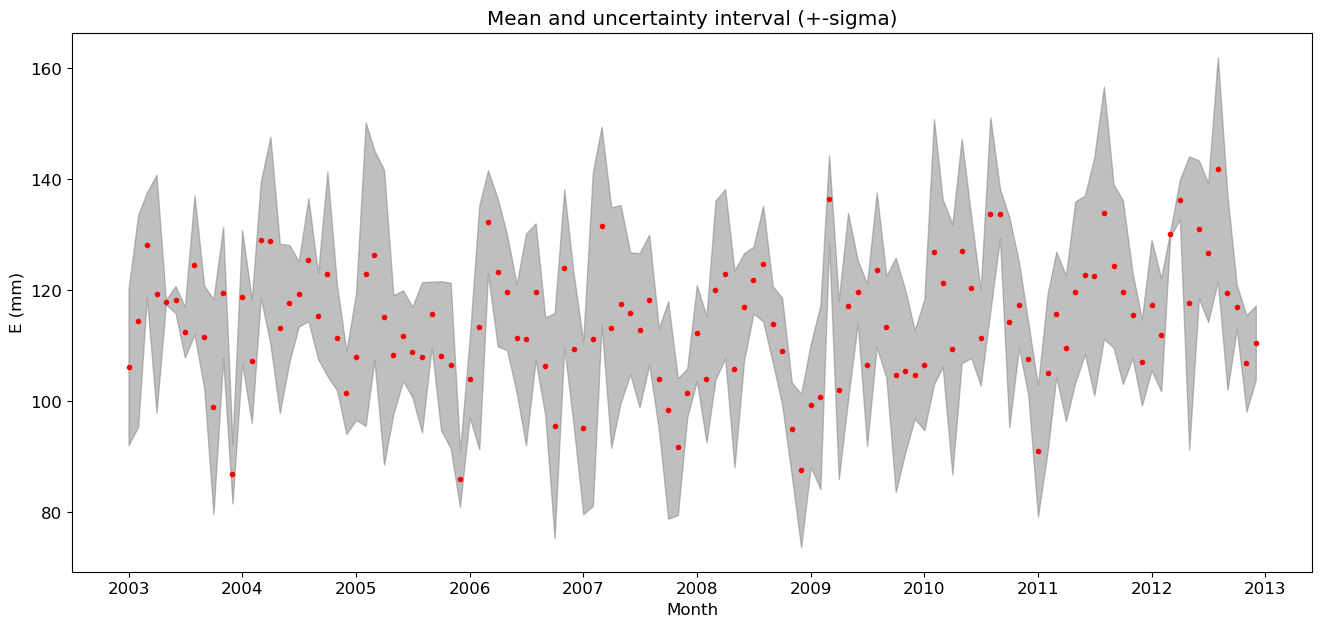

In [9]:
# Plot monthly mean and uncertainty interval (+-sigma) of evaporation
plt.figure(figsize=(16,7))
plt.fill_between(gldas_monthly.index, mE - np.sqrt(vE), mE + np.sqrt(vE), color='grey', alpha=0.5)
plt.plot(mE, 'r.')
plt.xlabel('Month')
plt.ylabel('E (mm)')
plt.title('Mean and uncertainty interval (+-sigma)');

# Discharge

In [10]:
#Shape area
shape_area_Cagayan = 1083.18 * 1000000 # m2

# Discharge data Cagayan de Oro
obs = pd.read_excel('Discharge_19912019_Cagayan.xlsx', index_col=[0])
obs = obs / 1000 # m3/s
obs = obs * 86400 / shape_area_Cagayan * 1000 # mm/day
obs.loc[obs['Q'] > 4000, 'Q'] = np.nan
obs = obs.loc['2003-01-01':'2012-12-31']
obs_monthly = obs.resample('MS').sum() # mm/day 

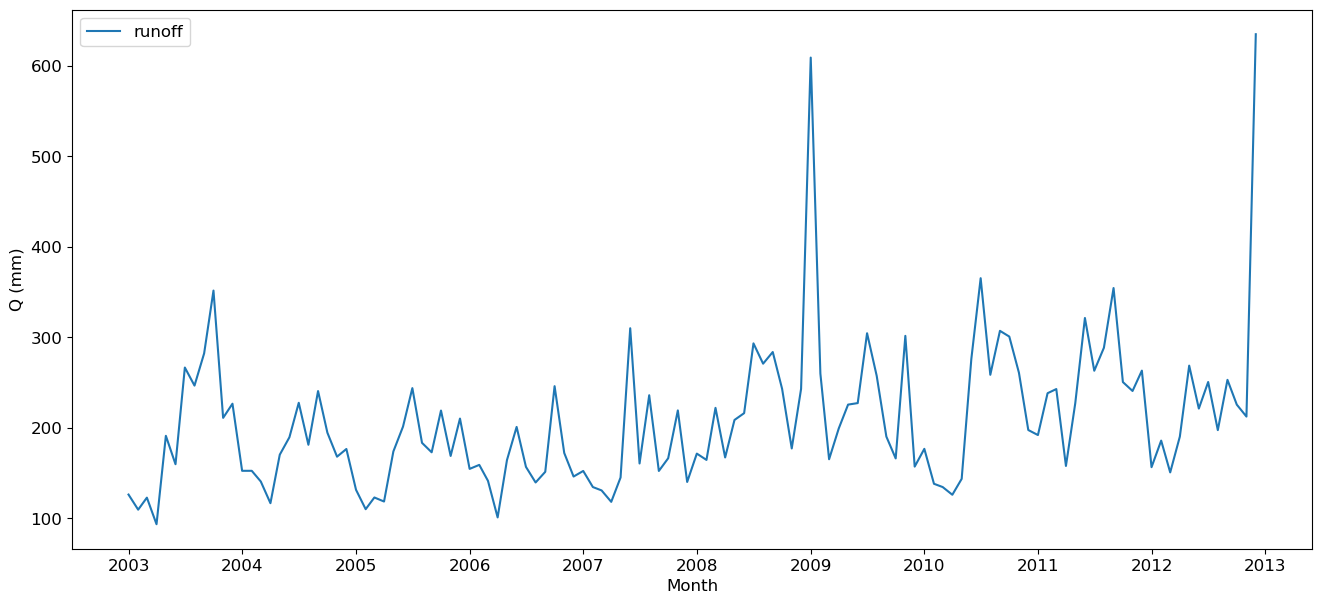

In [11]:
QObs = obs_monthly['Q']
plt.figure(figsize=(16,7))
plt.plot(QObs, label='runoff')
plt.legend()
plt.xlabel('Month')
plt.ylabel('Q (mm)');

In [12]:
# Compute monthly mean mQ and variance vQ of river discharge
mQ = QObs
vQ = np.square(0.1 * QObs)
print(mQ[0], vQ[0])

126.27961668420761 159.46541589910407


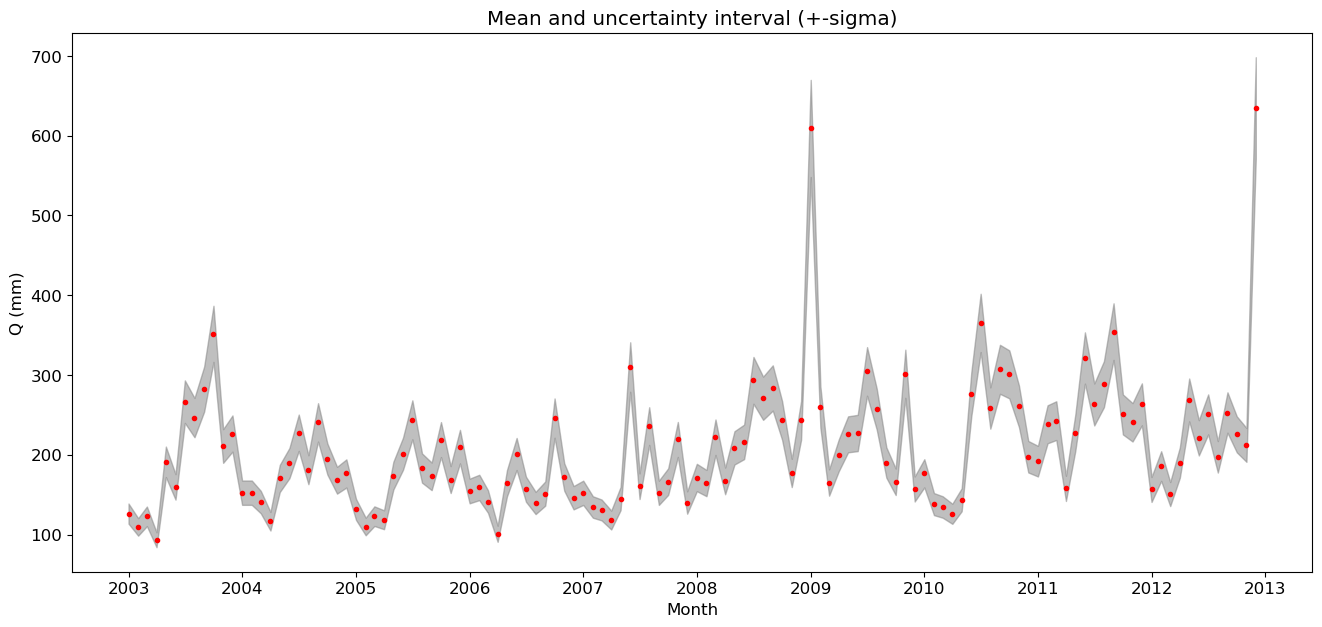

In [13]:
# Plot monthly mean and uncertainty interval (+-sigma) of river discharge
plt.figure(figsize=(16,7))
plt.fill_between(obs_monthly.index, mQ - np.sqrt(vQ), mQ + np.sqrt(vQ), color='grey', alpha=0.5)
plt.plot(mQ, 'r.')
plt.xlabel('Month')
plt.ylabel('Q (mm)')
plt.title('Mean and uncertainty interval (+-sigma)');

# Storage

In [14]:
# Loading the data
grace = pd.read_csv('./Data/grace.csv') # cm
grace_error = pd.read_csv('./Data/grace_error.csv') #cm

# Seting the units to mm
grace['date'] = pd.to_datetime(grace['system:index'].str.split('_').str[0], format='%Y%m%d')
grace.set_index('date', inplace=True)
grace.drop(columns=['system:index'], inplace=True)
grace['lwe_thickness'] = grace['lwe_thickness'] * 10 # mm
full_date_range = pd.date_range(start=era5P.index.min(), end=era5P.index.max(), freq='D')
grace = grace.reindex(full_date_range, fill_value=pd.NA)
grace = grace.resample('MS').mean()

grace_error['date'] = pd.to_datetime(grace_error['system:index'].str.split('_').str[0], format='%Y%m%d')
grace_error.set_index('date', inplace=True)
grace_error.drop(columns=['system:index'], inplace=True)
grace_error['uncertainty'] = grace_error['uncertainty']  * 10 # mm
grace_error = grace_error.reindex(full_date_range, fill_value=pd.NA)
grace_error = grace_error.resample('MS').mean()

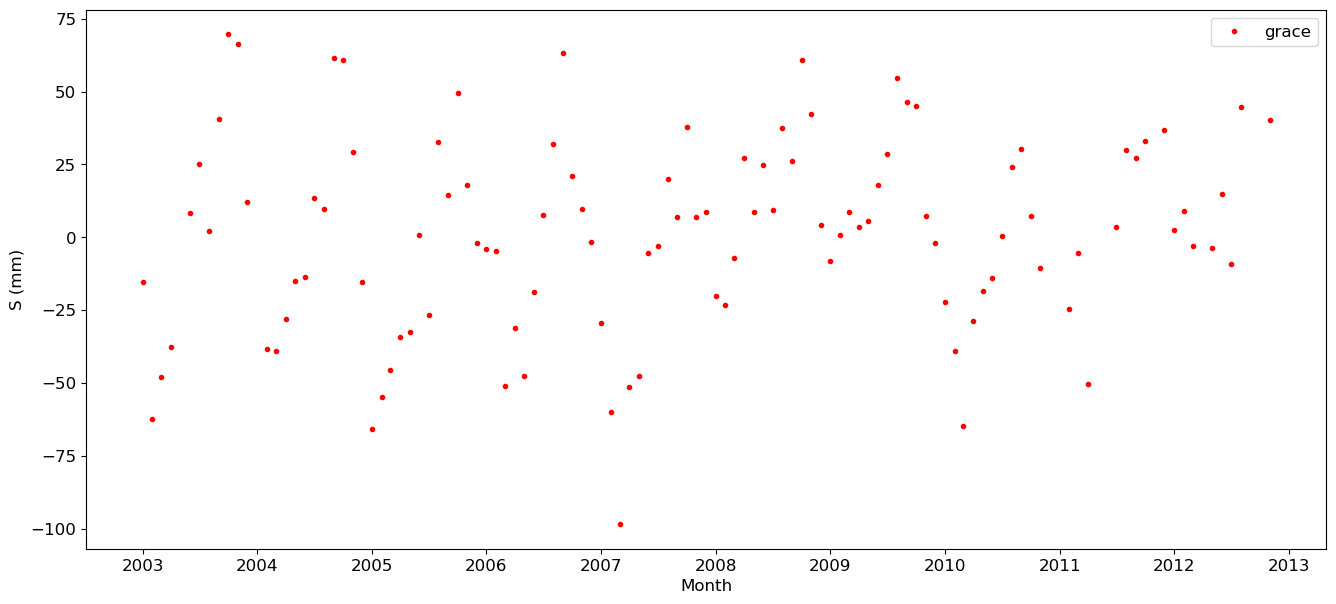

In [15]:
SObs = grace['lwe_thickness']
sigmaSObs = grace_error['uncertainty']
plt.figure(figsize=(16,7))
plt.plot(SObs, 'r.', label='grace')
plt.legend()
plt.xlabel('Month')
plt.ylabel('S (mm)');

In [16]:
# Compute monthly mean mS and variance vS of water storage
mS = SObs
vS = np.square(sigmaSObs)
# nodata = np.where(SObs == -99999)
# mS[nodata] = np.nan #use nan for plotting
# vS[nodata] = np.nan
print(mS[0], vS[0])

-15.20158006440084 928.4836929911024


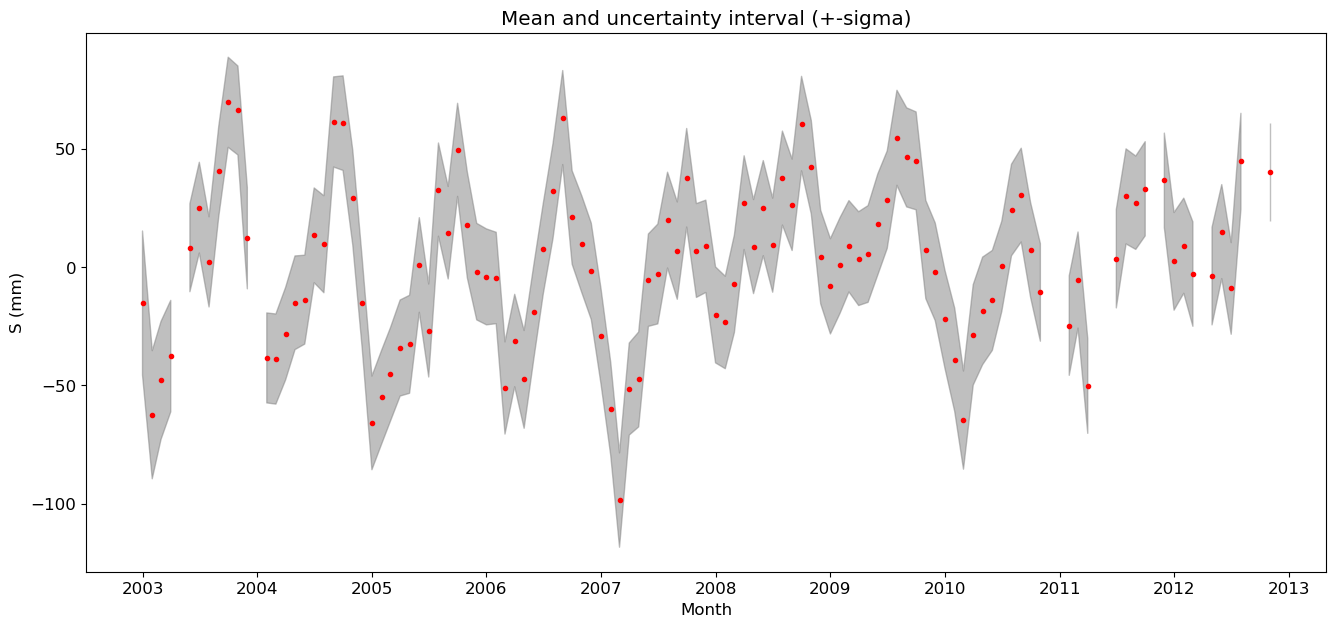

In [17]:
# Plot monthly mean and uncertainty interval (+-sigma) of water storage
plt.figure(figsize=(16,7))
plt.fill_between(grace.index, mS - np.sqrt(vS), mS + np.sqrt(vS), color='grey', alpha=0.5)
plt.plot(grace.index, mS, 'r.')
# plt.ylim(-200, 100)
plt.xlabel('Month')
plt.ylabel('S (mm)')
plt.title('Mean and uncertainty interval (+-sigma)');

# 
SObs = np.copy(SObs)
# mS[nodata] = 0
# vS[nodata] = 1e+9

# PART 2: Uncertainty propagation and Gaussian product

This part of the exercise was for ilustration of the concept of the uncertainty propagation and Gaussian product and is therefor skipped with approval of Gerrit.

In [18]:
# Gaussian Product

def gaussian_product(m1, v1, m2, v2):
    w1 = v2 / (v1 + v2)
    w2 = 1 - w1
    m = w1 * m1 + w2 * m2
    v = w1 * v1#or w2*v2
    return m, v

# PART 3: Kalman filtering and smoothing

In [19]:
def close_water_balance(mP, vP, mE, vE, mQ, vQ, mS, vS):
    # Specify prior mean and variance for initial storage S0 (first month)
    mS0 = 0
    vS0 = 200 * 200#large variance to indicate large uncertainty
    
    # Initialize posteriors
    # We compute these in forward loop (filtering posteriors) and then update them in backward loop (smoothing posteriors)
    nt = len(mP)#number of months in time-series
    mPostP = np.zeros(nt)#posterior mean of precipitation in each month
    vPostP = np.zeros(nt)#posterior variance of precipitation in each month
    mPostE = np.zeros(nt)#etc...
    vPostE = np.zeros(nt)
    mPostQ = np.zeros(nt)
    vPostQ = np.zeros(nt)
    mPostS = np.zeros(nt)
    vPostS = np.zeros(nt)
    
    # Forward loop (filtering)
    for t in range(nt):
        # Step 1: predict - compute forward distribution to S
        if t == 0:
            mFromS0, vFromS0 = mS0, vS0
        else:
            mFromS0, vFromS0 = mPostS[t-1], vPostS[t-1]
        mToS = mFromS0 + mP[t] - mE[t] - mQ[t]
        vToS = vFromS0 + vP[t] + vE[t] + vQ[t]
        # Step 2: update - compute filtering posterior of S
        mPostS[t], vPostS[t] = gaussian_product(mToS, vToS, mS[t], vS[t])

    # Backward loop (smoothing)
    mToS, vToS = 0.0, 1e+9#represents backward distribution to S - initialize to wide Gaussian for last month
    for t in reversed(range(nt)):
        # Step 1: smoothing posterior of S
        mPostS[t], vPostS[t] = gaussian_product(mToS, vToS, mPostS[t], vPostS[t])
        # Step 2: posteriors of P, E, and Q
        mFromS, vFromS = gaussian_product(mToS, vToS, mS[t], vS[t])
        if t == 0:
            mFromS0, vFromS0 = mS0, vS0
        else:
            mFromS0, vFromS0 = mPostS[t-1], vPostS[t-1]
        mdiff = mFromS0 - mFromS
        vdiff = vFromS0 + vFromS
        mPostP[t], vPostP[t] = gaussian_product(-mdiff + mE[t] + mQ[t], vdiff + vE[t] + vQ[t], mP[t], vP[t])
        mPostE[t], vPostE[t] = gaussian_product(mdiff + mP[t] - mQ[t], vdiff + vP[t] + vQ[t], mE[t], vE[t])
        mPostQ[t], vPostQ[t] = gaussian_product(mdiff + mP[t] - mE[t], vdiff + vP[t] + vE[t], mQ[t], vQ[t])
        # Step 3: backward distribution to S0
        mToS = mFromS - mP[t] + mE[t] + mQ[t]
        vToS = vFromS + vP[t] + vE[t] + vQ[t]
        
    # After backward loop: compute posterior mean and variance of S0 (initial storage first month)
    mPostS0, vPostS0 = gaussian_product(mS0, vS0, mToS, vToS)
    
    # Return final water balance estimates (posterior means and variances of monthly estimates)
    return mPostP, vPostP, mPostE, vPostE, mPostQ, vPostQ, mPostS, vPostS, mPostS0, vPostS0

In [20]:
# Fill the NaN values
mS = mS.fillna(0)
vS = vS.fillna(1e+9)

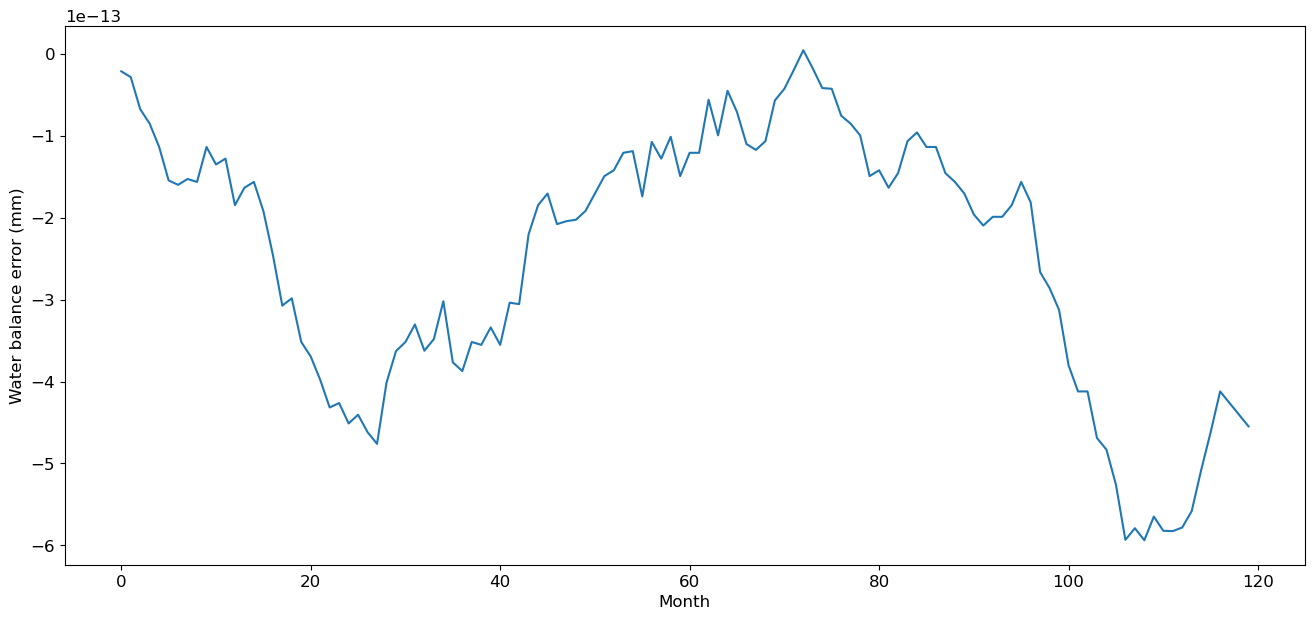

In [21]:
mPostP, vPostP, mPostE, vPostE, mPostQ, vPostQ, mPostS, vPostS, mPostS0, vPostS0 = close_water_balance(mP, vP, mE, vE, mQ, vQ, mS, vS)

nt = len(mP)
Swb = np.zeros(nt)
for t in range(nt):
    if t == 0:
        Swb[t] = mPostS0 + mPostP[t] - mPostE[t] - mPostQ[t]
    else:
        Swb[t] = Swb[t-1] + mPostP[t] - mPostE[t] - mPostQ[t]
wbError = Swb - mPostS

plt.figure(figsize=(16,7))
plt.plot(wbError)
plt.xlabel('Month')
plt.ylabel('Water balance error (mm)');

In [22]:
def PlotPosterior(name, m, v, obs1, obs2, obs3, l1, l2, l3):
    mu = m
    sigma = np.sqrt(v)
    lower = mu - sigma
    upper = mu + sigma
    plt.figure(figsize=(16,7))
    plt.fill_between(np.arange(len(lower)), lower, upper, color='grey', alpha=0.5)
    plt.plot(mu, 'k')
    plt.plot(np.ma.masked_values(obs1, -99999), 'r.', label=l1)
    plt.plot(np.ma.masked_values(obs2, -99999), 'b.', label=l2)
    plt.plot(np.ma.masked_values(obs3, -99999), 'g.', label=l3)
    plt.ylabel(name)
    plt.legend()

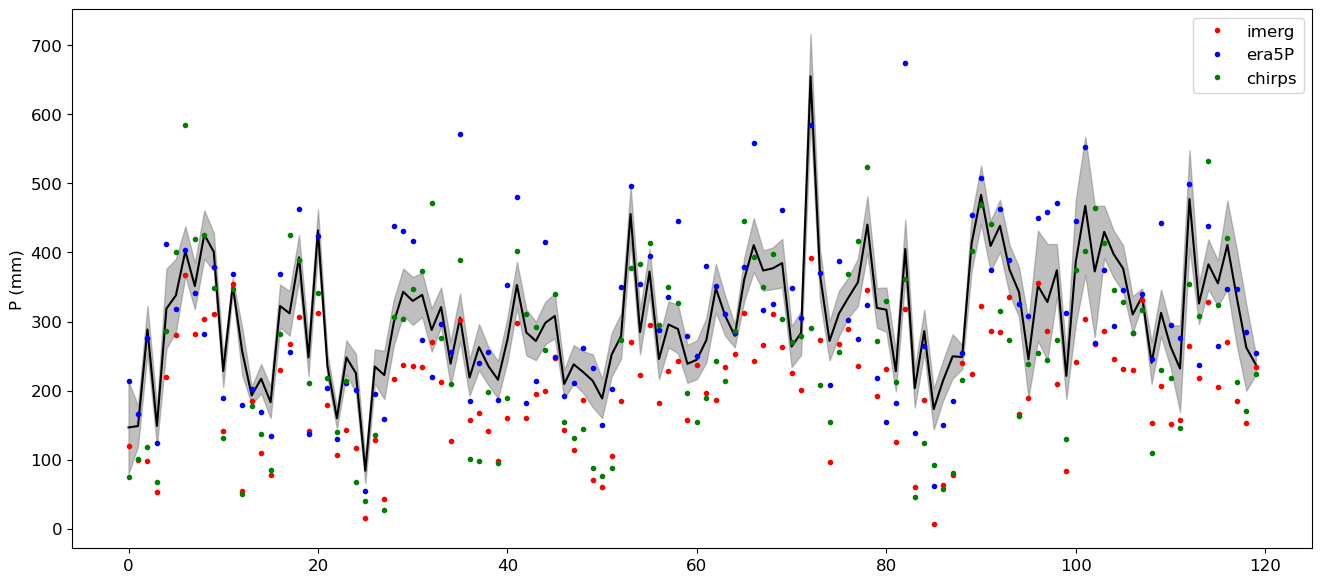

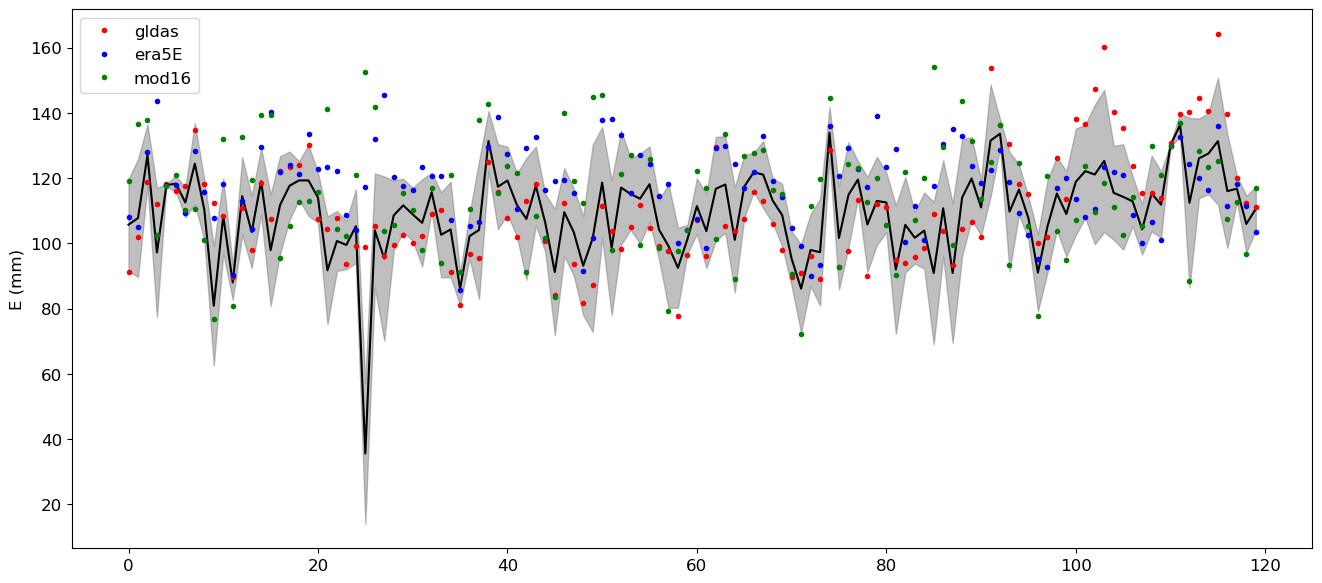

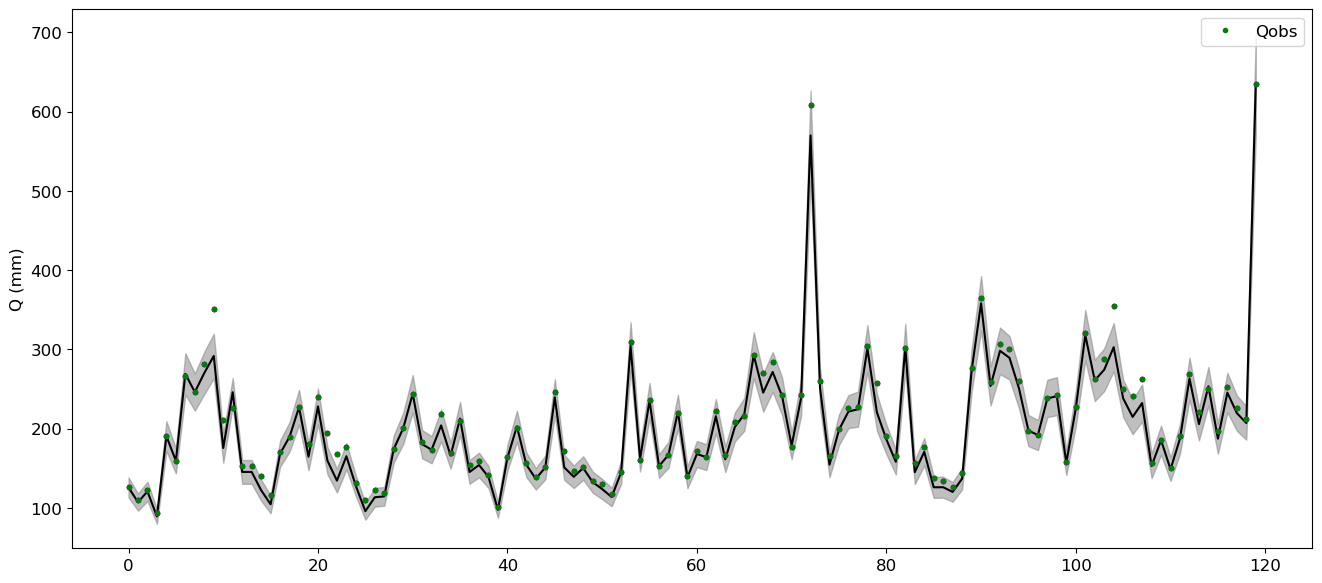

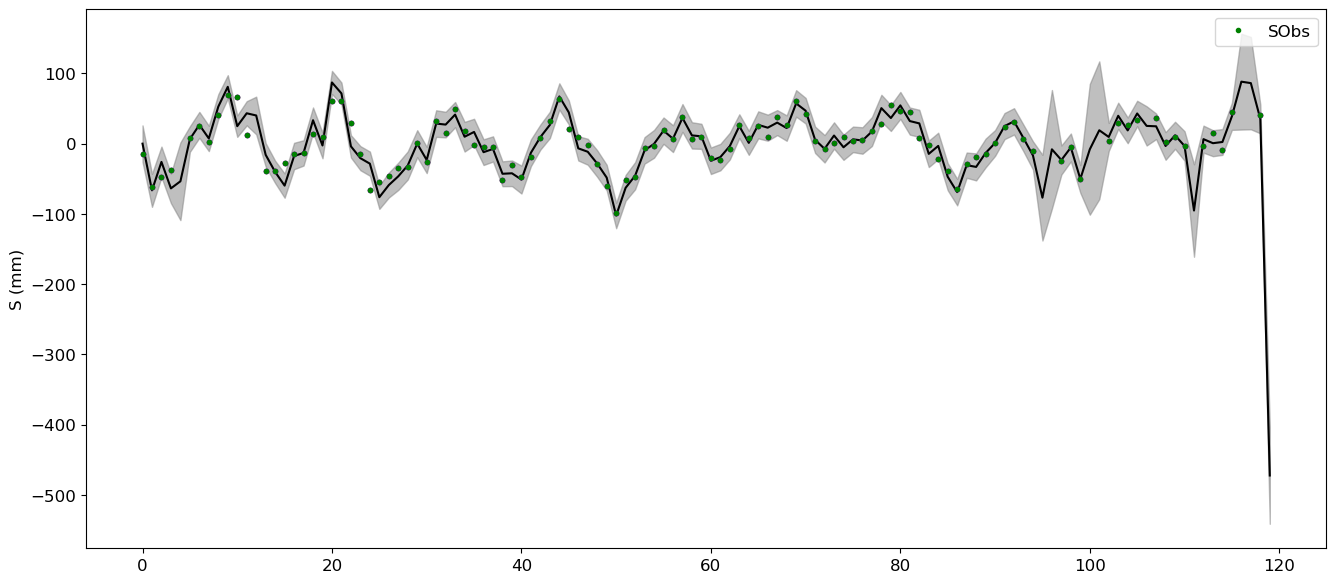

In [23]:
PlotPosterior("P (mm)", mPostP, vPostP, PObs1, PObs2, PObs3, 'imerg', 'era5P', 'chirps')
PlotPosterior("E (mm)", mPostE, vPostE, EObs1, EObs2, EObs3, 'gldas', 'era5E', 'mod16')
PlotPosterior("Q (mm)", mPostQ, vPostQ, QObs, QObs, QObs, '', '', 'Qobs')
PlotPosterior("S (mm)", mPostS, vPostS, SObs, SObs, SObs, '', '', 'SObs')